In [1]:
# https://raw.githubusercontent.com/Pankaj-Str/Complete-Python-Mastery/refs/heads/main/53%20DataSet/Mall_Customers.csv

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram , linkage
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

df = pd.read_csv("https://raw.githubusercontent.com/Pankaj-Str/Complete-Python-Mastery/refs/heads/main/53%20DataSet/Mall_Customers.csv")

print(df.head())

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


In [2]:
X = df[['Annual Income (k$)','Spending Score (1-100)']].values
scaler = StandardScaler()
X_scaler = scaler.fit_transform(X)

Z = linkage(X_scaler,method='ward')

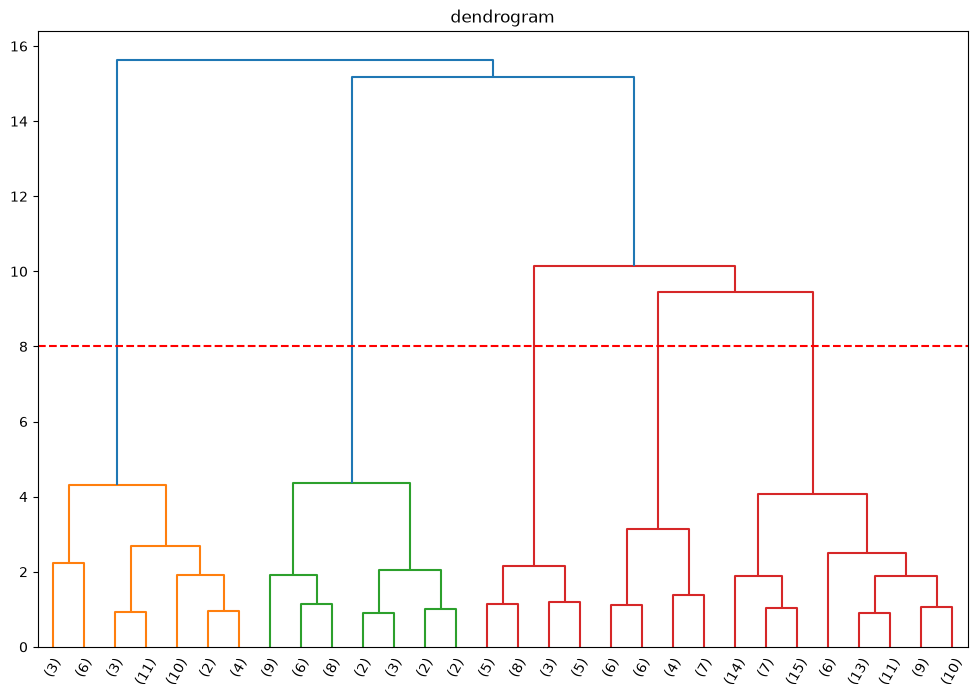

In [3]:
plt.figure(figsize=(12,8))
dendrogram(Z , truncate_mode='lastp',p=30,leaf_rotation=60)
plt.title("dendrogram")
plt.axhline(y=8,color='r',linestyle='--')
plt.show()

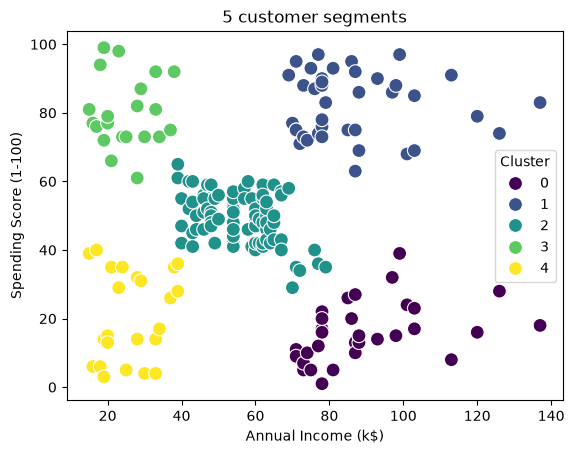

         CustomerID        Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                                   
0        166.250000  41.000000           89.406250               15.593750
1        162.000000  32.692308           86.538462               82.128205
2         87.894118  42.482353           55.811765               49.129412
3         22.000000  25.333333           25.095238               80.047619
4         23.000000  45.217391           26.304348               20.913043

 Silhouette Score  0.5538089226688662


In [4]:
hc = AgglomerativeClustering(n_clusters=5,metric='euclidean',linkage='ward')
df['Cluster'] = hc.fit_predict(X_scaler)
# print(df['Cluster'])
sns.scatterplot(data=df,x='Annual Income (k$)',y='Spending Score (1-100)',
                hue='Cluster',palette='viridis',s=100)
plt.title('5 customer segments')
plt.show()

print(df.groupby('Cluster').mean(numeric_only=True))
print('\n Silhouette Score ',silhouette_score(X_scaler,df['Cluster']))